**NOTE: ** Try to make a *copy of thise fil*e to make changes or to run so main code pipeline doesn't get impacted.

# Mechanistic Uniqueness in Tiny Neural Networks


---

Mechanistic Interpretability (MI) aims to explain how neural networks implement functions internally.  
Recent work (Meloux et al., 2025) shows that multiple distinct internal circuits can perform the same computation (which raises questions about identifiability).
Here, we will attempt to do the following:  
1. Empirically demonstrate non-unique circuits in a simple model.  
2. Quantify how circuit multiplicity and similarity might change with architecture size and regularization.  
3. Lay groundwork for identifying when *unique* explanations might exist.



---

The code will first use a small multilayer perceptron (MLP) trained on the XOR task, we then systematically enumerate all subsets of hidden neurons ("circuits") and test whether each subset alone reproduces the network’s behavior.  


### Some Key Concepts:
These are included to help provide one with a better conceptual background with the topics.


---
A neural network is made up of neurons (nodes) connected by weights (edges). Each neuron receives inputs, performs a simple computation (like a weighted sum and activation), and sends its output to other neurons. However, it's often unclear how the internal components cooperate to produce specific outputs (especially when you train the model to perform more complex tasks). Mechanistic interpretability tries to solve this problem via identifying mechanistic explanations (which is sort of descriptions of how certain parts of the network perform specific computations).

In this context, a circuit is a small *subgraph* of the network (a subset of neurons and their connecting weights) that performs a specific computation (or contributes to a particular behavior).
A mechanistic explanation pairs this circuit with an interpretation of what it does. By the way, if removing/ablating that circuit breaks the function then it is casually important.

---
### Relevant Vocab:

**Neuron:** a single comoutational unit that takes inputs, applies a function, and outputs a value.

**Weight:** a learned parameter which controls how strongly one neuron influences another.

**Circuit:** a subset of neurons and their connecting weights that (when isolated) reproduce a specific function or subcomputation of the full network.

**Valid Circuit:** a circuit whose output matches the full model's output closely enough (low error)

**Functional Equivalence:** two circuits produce the same input-output mapping (so they behave identically)

**Mechanistic Explanation:** a description of what a circuit *does* and how it contributes to the network's behavior. In essentially pairs the identified circuit with an interpretation (like "this subnetwork detects XOR parity").

**Unique explanation:** there is only one minimal, casually valid circuit that can perform a given behavior. In other words, this sort of means that the internal structure of the model corresponds to a single/consistent explanation.

**Non-unique explanation:** multiple circuits can produce the same input-output mapping (functionally equivalent but structurally different). In other words, there are many equally valid ways for the model to compute the same thing.



---



If explanations are non-unique then interpretability results can have ambiguity. For instance, different researchers can find different "valid" circuits for the same behavior. For example, two different groups of neurons might both solve XOR correctly (even though they use different internal pathways). If this happens, the model’s internal “reasoning” isn’t identifiable so we can’t say there’s one true explanation.



### Interpretability Identifiability Problem

MI (mechanistic interpretability) assumes that internal mechanisms of a trained network can be decomposed into identifiable functional parts (which are circuits that correspond to meaningful computations). However, if there are multiple distinct internal structures that can produce the same behavior then this mapping from internal components to function becomes *non-identifiable*. In other words, there may be no single correct mechanistic explanation.

Multiple internal pathways can generate the same observed behavior.

Hopefully for us, by perhaps understanding how uniqueness works, we could perhaps clarify when interpretability findings can or cannot be trusted as unique explanations.

### Suggested Reading & References

These are papers and resources which can help provide a deeper background and conceptual grounding for the ideas explored in this notebook. I would suggest exploring these for preliminary concepts (*note*: you do not have to read every single word but you should aim to be roughly familiar with the main concepts). Reading the first paper is encouraged but rest are all fully optional.


---

**Base paper:** https://arxiv.org/abs/2502.20914

This is probably the best paper to read since this paper is like the basis of this project. When I originally read it, the paper basically showed non-uniqueness is prevalent even in small models but this raised some questions for me. For instance, I was thinking the following:
"when is an explanation unique? What determines how many distinct circuits exist for a behavior? Can explanation redundancy be mitigated/measured?" I then scoped my thoughts into an idea: for a given behavior (in a small network), how many mechanistic explanations exist?

Nevertheless, this got me thinking under what conditions would uniqueness hold (or cannot). What structural/training conditions would a model have a single minimal circuit that implements a given behavior?

They did not fully answer our current research question. They demonstrated and quantified non-uniqueness (so multiple mechanistic explanations can exist for the same function) but they did not formally characterize when or why uniqueness might hold. Nor did they derive conditions for identifiability.

In other words, they showed the problem exists; but we will try to find/explore the structure and causes of that problem and the boundaries where it might disappear.

**Information regarding paper:** the paper essentially demonstrated that even small neural networks can admit multiple, structurally distinct internal circuits that implement the same function. Their exhaustive enumeration of circuits in tiny multilayer perceptrons (MLPs) performing Boolean tasks further revealed that non-unique mechanistic explanations are pervasive. So as network size increased, the number of valid internal explanations grew dramatically (which is indicating that mechanistic interpretability, as currently practiced, may be non-identifiable). Questions such as how architectural symmetry, overparameterization, weight redundancy, or training regularization influence identifiability remain open (which is what we will somewhat focus on).

Quick Summary of what they did:

* They empirically enumerated circuits (for Boolean tasks on small MLPs).

* They compared the following two search paradigms: “circuit-first” and “algorithm-first.”

* They showed that as model size increases, the number of valid explanations grows exponentially.

* They concluded that mechanistic interpretability is non-identifiable, since multiple distinct internal explanations produce the same input-output mapping.

It is notable that they did not do the following though:

* They did not formalize or measure uniqueness conditions
* They did not fully analyze how architecture or training choices affect identifiability.
* They stopped short of deriving/proposing a framework to predict/guarantee uniqueness.
* Their results are not diagnostic (were more descriptive).

Our project is sort of a second-order research question but it should hopefully consolidate relative work in the field of MI. The long-term goal regarding this topic is to answer: when can a neural network’s internal mechanisms be said to have a unique explanation?

**Recap**: Meloux et al. (2025) demonstrated empirically that mechanistic explanations are often non-unique, even in small MLPs. However, their analysis was primarily descriptive as they showed that multiple valid explanations exist but they did this without characterizing when or why such non-uniqueness arises. Our work will hopefully extend this line of inquiry by investigating the structural and training conditions under which mechanistic explanations may become unique or nearly unique.



---


 **Other papers/resources (which you can explore):**

 The paper above is probably the most important and relevant paper to our idea but here are some other choices if you want some more reading. I put these here because it also shows someone how MI papers are usually like as well. It might be more fruitful getting familiar with the concepts in this research idea but you can still read these anyway (if really desired).

https://arxiv.org/abs/2505.01372

Tha paper tries to systematically evaluate and improve explanations in MI. It's not related to uniqueness but it can still be worth exploring (since it talks about mechanistic explanations which is a crucial topic in MI)

https://arxiv.org/abs/2505.00808

This is another paper that might not be that significantly relevant to our topic but it helps you understand mechanistic interpretability more. It can also be worth checking out if you want to become familiar with how MI papers are usually like.

https://arxiv.org/abs/2411.16105

This paper is cool to read. Tt is mostly about circuit generalization  which is somewhat adjacent to ‘multiple circuits implement same behavior’ but we would need to connect it if we decided to do that. Nevertheless, it isn't that significant to our project other than that. It doesn’t focus on enumeration or uniqueness counts, and it’s more about generalization of a known circuit.

---
**Concepts**

To try to understand what Mechanistic Interpretability actually is, I would recommending watching these videos (in the following order)

* https://www.youtube.com/watch?v=sISodZSxNvc&pp=ygUcbWVjaGFuaXN0aWMgaW50ZXJwcmV0YWJpbGl0eQ%3D%3D

* https://www.youtube.com/watch?v=UGO_Ehywuxc&pp=ygUcbWVjaGFuaXN0aWMgaW50ZXJwcmV0YWJpbGl0eQ%3D%3D

I recommend reading this as it could provide you a better idea on what circuits are (not a research paper by the way): https://ytcs.github.io/machine-learning/2025/05/25/mechanistic-interpretability-part-1.html


---


**Miscellaneous:**

https://www.youtube.com/watch?v=JfukUIB3JDE

https://www.youtube.com/watch?v=rEDzUT3ymw4&pp=ygUdbmVydW9ucywgd2VpZ2h0cywgY2lyY3VpdHMgYWk%3D (neurons in 1 minute)

https://en.wikipedia.org/wiki/Mechanistic_interpretability



---



Note: you do not have to go through every resource here but these are provided to help speed you up into the research idea. Getting a rough familarity with the concepts will make it easier for you to understand. I also have explained some concepts that are being used in the code blocks (either above/below it or in the code block).

### Necessary Imports

Putting all imports at top for better organization

In [ ]:
!pip install torch torchvision tqdm networkx numpy matplotlib
!pip install seaborn plotly

import torch
import torch.nn as nn
import torch.optim as optim
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import networkx as nx
from itertools import combinations
from tqdm import tqdm

### Circuits

Before we get started, you should hopefully have a rough idea on what a *circuit* is. Skim this section if you are slightly confused because circuits are like the backbone of this research question.

To recapitulate, a **circuit is a subset of neurons and connections(weights)** within a neural network that is causally sufficient to perform a specific computation or sub-function of the overall model. In other words, it can be thought of as a a functional subgraph (which is a small piece of the model’s computation graph that explains how the network implements a certain behavior).

Other information:

* Circuits are the mechanistic units of explanation in MI.

* They viaduct between neuron-level feature attribution and function-level abstraction.

* If multiple circuits exist for one behavior, the mechanistic explanation is non-unique.

* Thus, the enumeration of circuits is the measurement of interpretability identifiability.

More about circuits:

* If removing any neuron/edge breaks the behavior, the circuit is minimal. Minimality ensures parsimony of explanation (avoids redundant neurons). Essentially, a circuit is minimal if no subset of its nodes/edges can reproduce the same function.
* Casual validity is when *the rest* of the network is ablated (or replaced by identity), *the circuit reproduces* the target behavior (within tolerance). In other words, a circuit is causally valid if interventions/ablations confirm **it** performs the computation.

Here is an example:

Let's say we have a tiny 2–2–1 MLP trained on XOR:
* Each hidden neuron may learn a nonlinear basis function (e.x. 'AND' or 'OR')
* The output neuron may combine them linearly to produce XOR.
* But because of weight symmetries, two different pairs of hidden neurons might perform equivalent transformations.

In this case, there could be two distinct minimal circuits implementing XOR. They both are functionally valid but using different sets of neurons.

By the way, a behavior/function is the target computation we’re trying to explain mechanistically. For instance, it can be the mapping from input to output that the model implements (like an XOR truth table). Mechanistic explanation is sort of the broader term that includes both the circuit and its conceptual interpretation.
So an explanation = (circuit, interpretation). Also, equivalent explanations produce the same function, even if circuit structure differs.

### Setting up Tiny MLP Model


---


We define a 2–4–1 MLP with a single hidden layer and ReLU activation.  
This simple architecture should be expressive enough to learn the XOR function while remaining small enough to exhaustively enumerate all hidden-neuron subsets later.

By the way, XOR (exlucsive OR) was chosen since the task is small but nonlinear (so it can’t be solved by a single linear transformation). Thus, the model must *combine* multiple neurons in a specific way (which creates potential for multiple internal implementations).
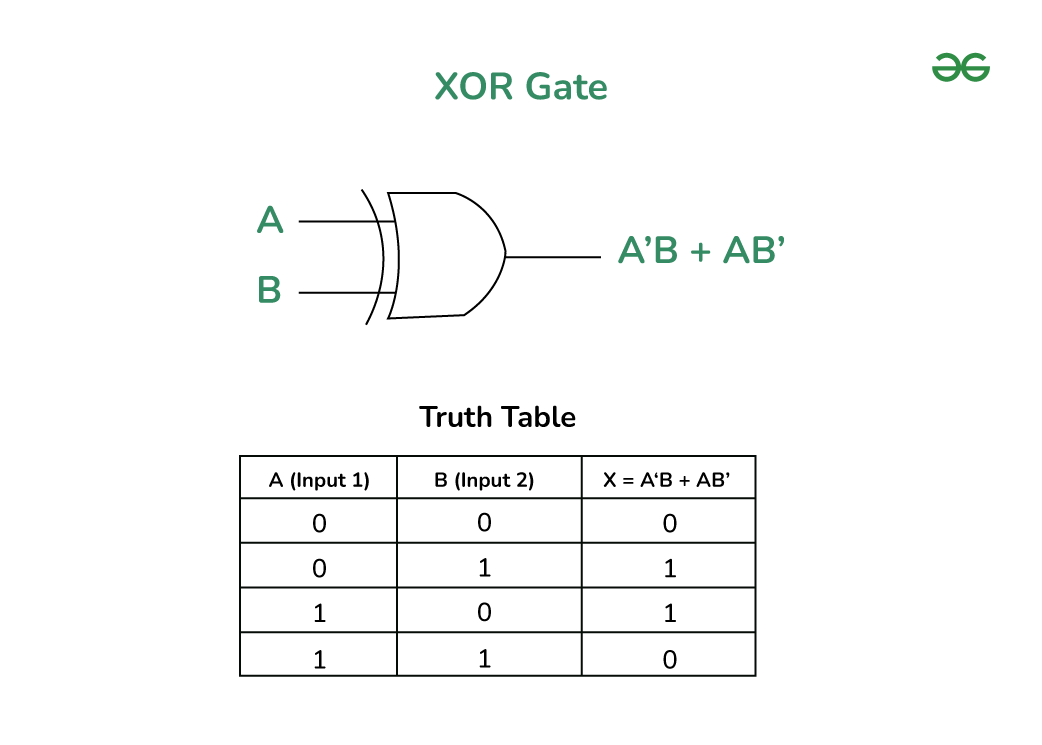

The XOR (exlusive OR) task is pretty much a classic nonlinear Boolean task where it takes in two binary inputs and it will output 1 if input is 1 (otherwise it will output 0). Essentially it is XOR(x1, x2) = (x1,x2) mod 2

It is widely used as a minimal test case in neural network research especially due to the fact XOR cannot be represented by a single linear function (thus it demands a hidden layer). This will force the network to develop internal nonlinear representations (this should help us since we are aiming to find out how neurons work together to compute a function).

AND / OR / NAND / NOR are other simpler Boolean baselines. We could have also done simple continous tasks like a 1D regression (y=sin(x)).

In [ ]:
class TinyMLP(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=4, out_dim=1):
        super().__init__() # Input to Hidden
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        # Nonlinearity
        self.relu = nn.ReLU() # goes from hidden to input
        self.fc2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x): # forward pass through the network
        h = self.relu(self.fc1(x))
        out = self.fc2(h)
        return torch.sigmoid(out)  # binary output (between 0 to 1)

### ReLU Activation Function

In the code block above, we use a Rectified Linear Unit (ReLU) activation. This is to introduce nonlinearity into neural networks (especially since solving problems like XOR that are not linearly separable).

ReLU(x) = max(0,x)

It outputs the input directly if it is positive, and zero otherwise. By the way, by zeroing out negative activation, ReLU induces sparsity in the hidden representations (as only some neurons are active for a given input).

Furthermore, the selective activation in this context allows the network to represent multiple distinct computational pathways and can therefore interact with circuit multiplicity: different subsets of neurons may become responsible for the same function depending on activation patterns.

### Generating a Simple Task (XOR)


---

We construct the full truth table for XOR.  
Inputs are the four possible binary pairs; targets are 0 for equal bits and 1 otherwise.


In [ ]:
def make_xor_data():
    X = torch.tensor([
        [0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]
    ])
    y = torch.tensor([[0.], [1.], [1.], [0.]])
    return X, y

### Model Training


---


We train the network using Adam and binary cross-entropy loss until it correctly models the XOR mapping.  
This step produces the reference behavior we will later try to reproduce using partial circuits.  

In [ ]:
def train_model(model, X, y, epochs=5000, lr=0.05):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for epoch in range(epochs):
        opt.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss.backward()
        opt.step()
    return model

### Circuit Evaluation Function


---
Given a subset of hidden neurons (a “circuit”), we temporarily mask all other neurons during the forward pass  
and compare the resulting outputs with those of the full model.  
If the mean-squared error (MSE) is below a threshold, we classify the subset as a *valid* circuit.  


In [ ]:
def evaluate_circuit(model, circuit, X, target_outputs, threshold=0.1):
    """
    circuit: tuple of neuron indices (e.g., (0, 2))
    Returns True if circuit reproduces the behavior (MSE < threshold)
    """
    with torch.no_grad():
        hidden_dim = model.fc1.out_features
        mask = torch.zeros(hidden_dim)
        mask[list(circuit)] = 1.0 #mask the hidden layer activations so only selected neurons contribute

        def hook_fn(module, inp, out):
            return out * mask

        h = model.fc1.register_forward_hook(hook_fn)
        outputs = model(X)
        #compute how well this reduced subnetwork reproduces the full output
        h.remove()

        mse = torch.mean((outputs - target_outputs) ** 2).item()
        return mse < threshold, mse, outputs.numpy()

        # We will next evaluate the circuits with a function  which will simulates running the network with
        # only a specific subset of hidden neurons and checks if the result is close enough to the original network's output on the same inputs.


### What is MSE?

Mean Squared Error (MSE) measures the average squared difference between two sets of values. In this case, this is going to be the outputs of a circuit and the outputs of the full model. Furthermore, a lower MSE indicates that the circuit reproduces the full model’s behavior more accurately.

For this project, we are using MSE as a functional equivalence criterion: circuits with low MSE are considered functionally similar to the original network (and thus “valid”).

### Enumeration Complexity

In this experiment, all possible subsets of hidden neurons are tested as potential circuits. For instance, If the hidden layer has
x neurons then there are 2^x - 1 possible non-empty subsets. However, it is notable to know this exponential growth makes full enumeration tractable only for very small networks (e.x. so x should be like less than 8).

### Circuit Enumeration


---


We enumerate every possible non-empty subset of hidden neurons and test each one using the evaluation function.  
By the way, this brute-force enumeration is feasible only for small networks but provides exact multiplicity counts of valid circuits.  

In [ ]:
def enumerate_circuits(model, X, y):
    """
    Enumerate all possible neuron subsets in the hidden layer
    and test if they reproduce the model's behavior.
    """
    print("Getting reference outputs...")
    with torch.no_grad():
        ref_outputs = model(X)

    hidden_dim = model.fc1.out_features
    all_neurons = list(range(hidden_dim))
    valid_circuits = []
    results = []

    print("Enumerating possible circuits...")
    for k in range(1, hidden_dim + 1):
        for subset in itertools.combinations(all_neurons, k):
            is_valid, mse, out = evaluate_circuit(model, subset, X, ref_outputs)
            '''
             The evaluate_circuit function will determine if given subset of hidden neurons
             (a "circuit") is "valid" by comparing the output of the model when only those
             neurons are active to the output of the full model.

             It will first create a mask based on the circuit (the tuple of neuron indices).
             This mask is a tensor with the same size as the hidden layer,
             where the values are 1.0 for the neurons in the circuit and 0.0 for all other neurons.

             Then, it will It registers a forward hook on the hidden layer (model.fc1). This hook is a function
             that modifies the output of the hidden layer during the forward pass. The hook multiplies the hidden layer's
             output by the mask created in the previous step.
              This will effectively "turns off" the neurons that are not in the current circuit.

              Then it performs a forward pass through the model with the hook in place.
              The hidden layer's output is masked, so only the selected neurons contribute to the final output.
              After the forward pass, the hook is immediately removed to ensure subsequent forward passes use the full network.
               It calculates the Mean Squared Error (MSE) between the outputs of the masked circuit and the target_outputs
               (which are the outputs of the full model on the same input data).

              It compares the calculated MSE to a predefined threshold. If the MSE is less than the threshold,
               the function considers the circuit to be "valid" because it reproduces the full model's behavior within an acceptable error margin.
            '''
            results.append((subset, mse))
            if is_valid:
                valid_circuits.append(subset)

    return valid_circuits, results

### Visualization

We visualize reconstruction error versus circuit size.  
A wide spread of valid circuits at different sizes indicates **non-uniqueness** so many distinct internal configurations yield the same external behavior.  

Training accuracy: 0.75
Getting reference outputs...
Enumerating possible circuits...

Valid Circuits Found: 8
  - (0,)
  - (0, 1)
  - (0, 2)
  - (0, 3)
  - (0, 1, 2)
  - (0, 1, 3)
  - (0, 2, 3)
  - (0, 1, 2, 3)



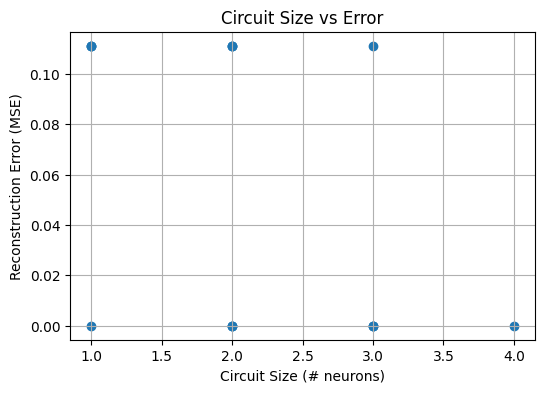

In [ ]:

def main():
    X, y = make_xor_data()
    model = TinyMLP()
    model = train_model(model, X, y, epochs=5000, lr=0.05)

    # Quick sanity check
    with torch.no_grad():
        preds = (model(X) > 0.5).int()
        print("Training accuracy:", (preds == y.int()).float().mean().item())

    # Enumerate circuits here
    valid_circuits, results = enumerate_circuits(model, X, y)

    print("\n==============================")
    print("Valid Circuits Found:", len(valid_circuits))
    for c in valid_circuits:
        print("  -", c)
    print("==============================\n")

    # Plot all circuits by size vs error
    sizes = [len(c) for c, mse in results]
    mses = [mse for c, mse in results]
    plt.figure(figsize=(6,4))
    plt.scatter(sizes, mses)
    plt.xlabel("Circuit Size (# neurons)") # indicates the number of hidden neurons included in the specific circuit being evaluated
    plt.ylabel("Reconstruction Error (MSE)") # shows how well the output of the circuit matches the output of the full model.
    # In essence,  a lower MSE means the circuit is a better approximation of the full model's behavior.
    plt.title("Circuit Size vs Error")
    plt.grid(True)
    plt.show()

    '''
    Circuits with an MSE below the defined threshold (0.1 in  evaluate_circuit function) are considered
    "valid" circuits that reproduce the full model's behavior.
    These would be the points below the horizontal line at y=0.1.

    Furthermore, if there are multiple points below the threshold at different circuit sizes,
    it indicates  that different combinations of neurons (circuits) can achieve the same functional output
    as the full network. This is demonstrating non-uniqueness.


    In the graph, (which is not strictly monotonic), you can kind of see a trend where larger circuits
    seem to have lower error (as they include more information from the original network).
    However, this is not always the case as smaller circuits are already sufficient to capture the
    essential information.

    '''

if __name__ == "__main__":
    main()

## RECAP

The code above will do the following:


1.   Trains a tiny 2 to 4 to 1 MLP on XOR (a non-linear Boolean task).
2.   Enumerates every possible subset of hidden neurons.
3.   For each subset, masks all other neurons and checks whether the model’s output still matches the full model (using MSE).
4.   Counts and prints all valid circuits that reproduce the behavior.
5.   Plots circuit size vs. reconstruction error.

This will be our minimum viable system or our core pipeline as it does the following:
1. Prove that multiple valid circuits can exist (non-uniqueness).
2. Generate numerical data about how many circuits exist for a fixed behavior.

However, we need additional code to study uniqueness rather than just observe it.

Non-uniqueness is also about how similar they are (rather than just how many circuits exist). Thus, we can measure overlap ratio (for each pair of valid circuits). Mean overlap implies how redundant circuits are. In other words, low overlap = high diversity (stronger non-uniqueness).

In [ ]:
def circuit_overlap(circuits):
    overlaps = []
    for i in range(len(circuits)): # will first loop through all unique pairs of valid circuits found.
        for j in range(i+1, len(circuits)):
            A, B = set(circuits[i]), set(circuits[j]) # For each pair of circuits, it converts them into sets of neuron indices (better for set operations)
            overlap = len(A & B) / len(A | B)
            '''
            The above calculates the intersection of the two sets (the neurons present in both Circuit A and Circuit B)
            and the union of the two sets (all unique neurons present in either Circuit A or Circuit B).
            This should give a value between 0 and 1, where 1 means the circuits are identical and 0 means they share no neurons.
            '''
            overlaps.append(overlap)
    return np.mean(overlaps) if overlaps else 0.0 #calculates the mean of these overlap ratios across all unique pairs of valid circuits

'''
A mean overlap closer to 0 would suggest that the valid circuits are diverse. So they are utilizing different combinations of neurons.
This would be a stronger form of non-uniqueness where the network finds multiple structurally distinct ways to perform the same computation.
On the contrary, close to 1 suggests that the valid circuits are largely redundant so they are using many of the same neurons to achieve the same outcome.
'''

'\nA mean overlap closer to 0 would suggest that the valid circuits are diverse. So they are utilizing different combinations of neurons.\nThis would be a stronger form of non-uniqueness where the network finds multiple structurally distinct ways to perform the same computation.\nOn the contrary, close to 1 suggests that the valid circuits are largely redundant so they are using many of the same neurons to achieve the same outcome.\n'

We are going to need controlled experiments so we can characterize when uniqueness holds. Thus, here are possible hyperparameters we can add:


1. L1 regularization (sparsity)
* promotes uniqueness
2. Weight decay / dropout
*  test effect on redundancy
3. Hidden size
*  check scaling of valid circuit counts



### What is L1 Regularization?

L1 regularization is essentially going to add a penalty proportional to the sum of the absolute values of all weights. This is going to encourage sparsity (where many weights will become exactly or nearly zero). This in effect will force the network to rely on fewer neurons/connections (which could reveal simpler or more 'unique' computational paths). So for us, this will reduce the redudant representations and it can make the internal circuitry more constrained/interpretable.

By the way, L1 and L2 (weight decay) are forms of regularization that prevent overfitting and influence internal representations differently.

Also, regularization just refers to techniques added during training to prevent overfitting (and to shape the internal representations of neural networks). This will directly affect the structure of internal computations (and will influence number/diversity of mechanistic explanations).

In [ ]:
experiment_results = []

X, y = make_xor_data()
for hidden_dim in [3, 4, 5, 6]:
    for l1 in [0.0, 1e-4, 1e-3]:
        print(f"Running experiment with Hidden dim: {hidden_dim}, L1: {l1}")
        model = TinyMLP(in_dim=2, hidden_dim=hidden_dim)

        # Train the model with L1 regularization
        opt = optim.Adam(model.parameters(), lr=0.05)
        loss_fn = nn.BCELoss()
        for epoch in range(5000):
            opt.zero_grad()
            y_pred = model(X)
            bce_loss = loss_fn(y_pred, y)
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            loss = bce_loss + l1 * l1_norm
            loss.backward()
            opt.step()

        # Enumerate circuits and calculate overlap
        valid_circuits, _ = enumerate_circuits(model, X, y)
        mean_overlap = circuit_overlap(valid_circuits)

        experiment_results.append({
            'hidden_dim': hidden_dim,
            'l1_reg': l1,
            'num_valid_circuits': len(valid_circuits),
            'mean_overlap': mean_overlap
        })

# Save results to a DataFrame and CSV
results_df = pd.DataFrame(experiment_results)
results_df.to_csv("uniqueness_experiments.csv", index=False)

print("\nExperiment results saved to uniqueness_experiments.csv")
print(results_df)

Running experiment with Hidden dim: 3, L1: 0.0
Getting reference outputs...
Enumerating possible circuits...
Running experiment with Hidden dim: 3, L1: 0.0001
Getting reference outputs...
Enumerating possible circuits...
Running experiment with Hidden dim: 3, L1: 0.001
Getting reference outputs...
Enumerating possible circuits...
Running experiment with Hidden dim: 4, L1: 0.0
Getting reference outputs...
Enumerating possible circuits...
Running experiment with Hidden dim: 4, L1: 0.0001
Getting reference outputs...
Enumerating possible circuits...
Running experiment with Hidden dim: 4, L1: 0.001
Getting reference outputs...
Enumerating possible circuits...
Running experiment with Hidden dim: 5, L1: 0.0
Getting reference outputs...
Enumerating possible circuits...
Running experiment with Hidden dim: 5, L1: 0.0001
Getting reference outputs...
Enumerating possible circuits...
Running experiment with Hidden dim: 5, L1: 0.001
Getting reference outputs...
Enumerating possible circuits...
Runn

Furthermore, instead of binary “valid or invalid,” we can define:

Functional similarity score = 1 - normalized MSE between circuit outputs and reference outputs.

This lets us plot a distribution of similarity scores across circuits.
Distributions of similarity scores will reveal whether circuit behaviors cluster around one dominant solution (implying uniqueness) or whether many near-equivalent circuits exist (indicating non-uniqueness). This is supposed to be like a spectrum of functional equivalence rather than a hard threshold.


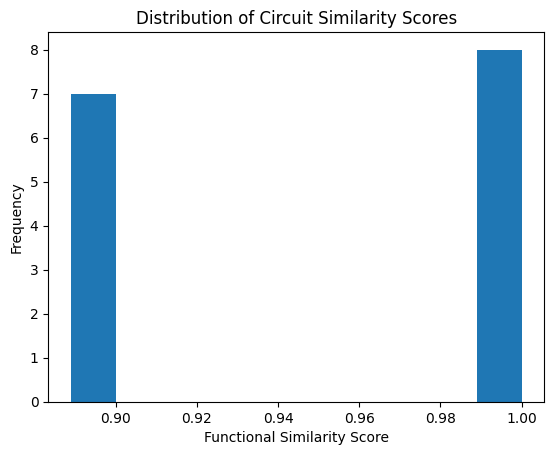

In [ ]:
def functional_similarity(model, circuit, X, ref_outputs): #provides a continuous measure of how closely a given circuit's output matches the output of the full original model
    with torch.no_grad():
        hidden_dim = model.fc1.out_features
        mask = torch.zeros(hidden_dim)
        mask[list(circuit)] = 1.0
        def hook_fn(module, inp, out):
            return out * mask
        h = model.fc1.register_forward_hook(hook_fn)
        out = model(X)
        h.remove()
        mse = torch.mean((out - ref_outputs)**2).item() # same MSE calculated in the evaluate_circuit function
    return 1 - mse #normalize and invert:

'''
As the MSE increases (meaning the circuit's output deviates more from the full model's output), the similarity score decreases.
A very poor match (high MSE) will result in a similarity score closer to 0 (though it won't go below 0 as MSE is non-negative).
Essentially, the functional similarity score quantifies how much of the full model's function is preserved by a specific circuit.
1 indicating perfect preservation and values closer to 0 indicating less preservation
'''
# Get reference outputs
X, y = make_xor_data() # will reuse make_xor_data
model = TinyMLP() # creating a new model instance
model = train_model(model, X, y) # Train the model
with torch.no_grad():
    ref_outputs = model(X)

# Get all possible circuits (subsets of hidden neurons)
hidden_dim = model.fc1.out_features
all_neurons = list(range(hidden_dim))
all_circuits = []
for k in range(1, hidden_dim + 1):
    for subset in itertools.combinations(all_neurons, k):
        all_circuits.append(subset)

# Calculate similarity for each circuit
similarities = [functional_similarity(model, circuit, X, ref_outputs) for circuit in all_circuits]

plt.hist(similarities, bins=10)
plt.title("Distribution of Circuit Similarity Scores")
plt.xlabel("Functional Similarity Score")
plt.ylabel("Frequency")
plt.show()


'''
This is my second time running the code from the top and I got the distrubution of similarity scores below.
So the circuits with scores close to 1 (like 0.9 or 1) are essentially the "valid" circuits.
They perform the same computation as the full network with very little error.

The results aren't that bad and are is direct evidence of non-uniqueness.
This means the network has multiple ways of performing the XOR task using different combinations of neurons.

'''

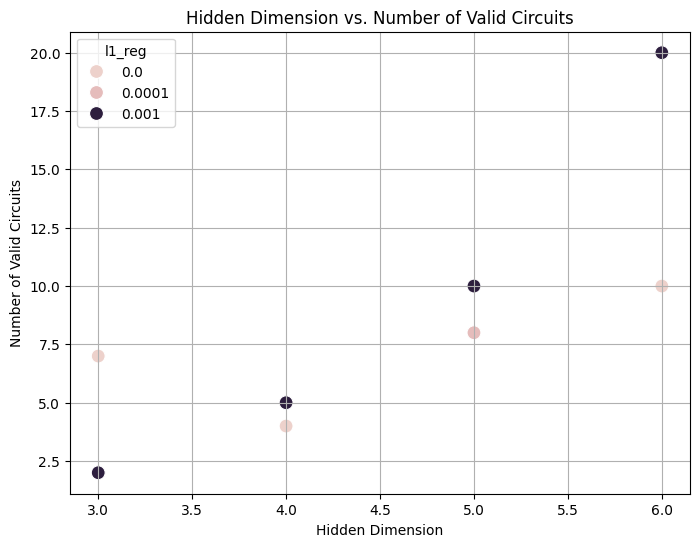

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=results_df, x='hidden_dim', y='num_valid_circuits', hue='l1_reg', s=100)
plt.title('Hidden Dimension vs. Number of Valid Circuits')
plt.xlabel('Hidden Dimension')
plt.ylabel('Number of Valid Circuits')
plt.grid(True)
plt.show()

***Note***: the following were my obvervations from my first time running the code (you will see the results of my second time running the whole code from scratch above but the observations are still pretty consisent).

Observations so far (from results_df DataFrame and the scatter plot of Hidden Dimension vs. Number of Valid Circuits):


*   Generally, as the hidden_dim (the size of the hidden layer) increases, the num_valid_circuits also tends to increase. This is expected because a larger hidden layer offers more combinations of neurons that could potentially reproduce the model's behavior.
*   The l1_reg (L1 regularization strength) seems to have an inverse relationship with the num_valid_circuits. For a fixed hidden_dim, higher values of l1_reg generally lead to a smaller num_valid_circuits. L1 regularization promotes sparsity in the weights, which can make the network rely on fewer neurons and potentially reduce the number of ways to achieve the same output.

 **Basically, it seems that increasing the hidden layer size increases the multiplicity of circuits, while L1 regularization tends to reduce this multiplicity.**

---

 Notably, the effect of L1 regularization on the overlap of the remaining circuits is not really that clear (but it might seem dependent on the network size)
*   While there isn't a single clear trend across all hidden dimensions, for some hidden dimensions, increasing L1 regularization seems to lead to a higher mean overlap among the valid circuits that remain. This could suggest that as L1 regularization prunes less essential neurons, the remaining valid circuits might become more similar in their composition. However, this relationship is not monotonic.




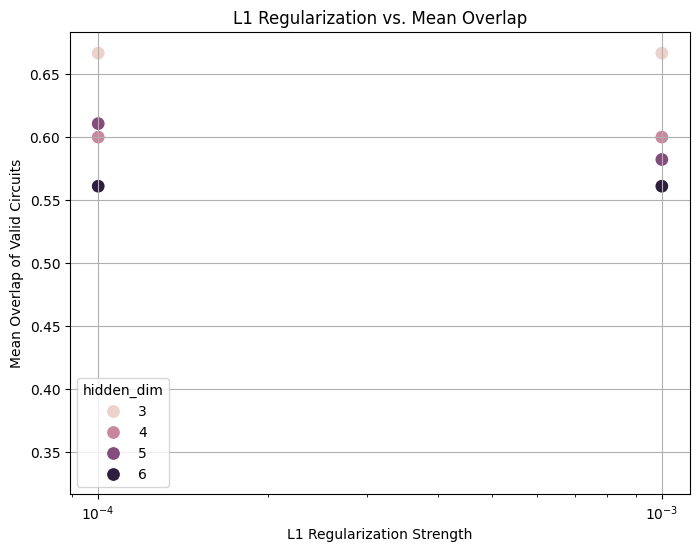

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=results_df, x='l1_reg', y='mean_overlap', hue='hidden_dim', s=100)
plt.title('L1 Regularization vs. Mean Overlap')
plt.xlabel('L1 Regularization Strength') # represents the strength of the L1 penalty applied during training.
plt.ylabel('Mean Overlap of Valid Circuits') #shows the average Jaccard index (intersection over union) of all unique pairs of valid circuits
'''
 A higher mean overlap means the valid circuits tend to share more neurons. This indicates more redundancy.
 A lower mean overlap means the valid circuits are more diverse in their neuron composition.
 This is indicating stronger non-uniqueness in terms of the specific neurons used.
'''
plt.xscale('log') # using a log scale for L1 regularization as values are small
plt.grid(True)
plt.show()

### Take-aways from plot above:

It is supposed to investigate whether L1 regularization that promotes sparsity (as it is driving some weights to zero) influences their compositional similarity (rather than just the number of valid circuits as seen in the previous plot).

Nevertheless, its effect on the compositional similarity (mean overlap) of the remaining valid circuits is not consistent across all network sizes.
L1 regularization will typically make the network more sparse; this often leads to fewer ways the network can achieve the correct output using different neuron subsets. Despite this, for the valid circuits that do remain after L1 regularization, their average overlap (how many neurons they share) doesn't follow a single clear pattern.

I think this suggests that L1 regularization's primary impact on "uniqueness" in this context is by reducing the count of valid circuits rather than consistently forcing the remaining valid circuits to be either more or less structurally similar to each other.

## Summary of what is going on (so far):

So far, we have demonstrated the following:


*  Non-unique mechanistic explanations empirically occur even in tiny MLPs trained on XOR.

* The number of valid circuits grows with hidden dimension (capacity).

* L1 regularization (sparsity) tends to reduce multiplicity.
  
This somewhat provides evidence for how arichtectural and training factors influence the existence/abudance of non-unqiue explanations.

We are still need to investigate to why or under what conditions a single unique circuit emerges (need casual factors rather than descriptive trends of multiplicity). We are able to observe non-uniqueness but we aren't probing its causes yet.

## Next Subexperiments which I will implement:
Here are of a couple ideas which I have to help us directly test when/why circuits become unique. I will add more but these should be good starters

1.   **Symmetry-breaking**

*   Planning on testing whether network symmetry contributes to non-uniqueness
*   Non-uniqueness will often arise from symmetries (so permuting neurons doesn't change function)
*   If symmetry-breaking reduces multiplicity, that supports the hypothesis that structural symmetry is a root cause of non-uniqueness

2.   **Weight Structure & Functionality**
*    Need to measure how redudancy in weights contributes to multiple explanations
*    Some neurons may learn near-identical weight vectors (which allows interchangeable circuits)
*   Thus, one could compute the cosine similarity between hidden neuron weight vectors then correlate average weight similarity with the number of valid circuits.
*   A high similarity could mean higher redudancy which means more non-unique circuits. A low similarity (which could imply orthogonal neurons) could potentially mean more unique explanations.

3. **Intervention or Ablation Validity**
*   Need to verify whether the circuits found are truly causal (and not just correlated)
*   After identifying a valid circuit, ablate (zero out) all other neurons and measure if performance is preserved. Then ablate that circuit and check if the model fails.
*  Circuits that preserve behavior under ablation are casually valid; others may be spurious. This will help us distinguish functionally equivalent but casually distinct circuits




### Possible Issues to Address

The code is currently working properly but I want to make it more rigorous so I am noting down things we should address. I mostly have all the solutions (which might work) to all the problems but I haven't implemented them yet. I will soon try to do so but I want to keep my thoughts organized. I will keep brainstorming other things which may need to be worked on here as well.



---


To start off, the "valid circuit" criterion (in the code) is currently checking for functional equivalence. However, it should be checking for casual necessity because functional equivalence is fine for establishing non-uniqueness but we need a notion for casual necessity for uniqueness characterization.

To illustrate this better, the code is essentially doing the following right now:

“Does this subset alone reproduce the behavior?”

Thus, I will soon add some ablation-based tests to test the following:

“Is this subset necessary for the behavior?”

Here is what we can implement:


*   A **causal sufficiency test** where we keep only the circuit alive to check whether the model still peforms correctly (we partly did some of this but it needs to be refined)
*   A **causal necessity test** where we remove this circuit (zero out all its neurons) and keep all others (does the model still fail?)


The thing is that a circuit is casually valid if it passes sufficiency and fails necessity. I think this is a good thing to add if we want to put more focus on mechanistic redudancy rather than functional redudancy.


---

We are currently using 1 - MSE as a similarity proxy but it is not bounded properly (nor normalized) especially across models with different output scales. Thus, I will change this soon to the following:

similiarity = 1 - MSE / Var(ref_outputs)

This should normalize the variance of the reference outputs. Another thing we can do is use a Pearson correlation between circuit outputs and full outputs. The correlation is scale-invariant and is interpretable as a 'functional alignment'.



---

The mean Jaccard overlap is not capturing the functional redudancy (only doing the structural redudancy). Thus, two circuits could share zero neurons yet compute nearly identical functions. So I will probably compare the structural overlap vs the functional similarity. Furthermore, if these correlate weakly then we can claim that non-uniqueness is functionally pervasive (not just structurally). Additionally, I will look into computing the pairwise functional similarity between circuits (using the similiarity score).



---

We are also missing random speeds and reproducibility. We can address this but we just need to make sure the trends we observe (like the effect of L1) are due to casual relationships rather than random initializations.


---

Threshold being 0.1 is kind of too arbitary. Alright for demonstration but it can still bias the number of valid circuits. We can look into showing how the number of valid circuits changes with different thresholds but we can for now just compute the empirical distribution of MSEs across all circuits to then define the threshold as quaritle (so it can be like top 5% of most accurate circuits).



---
```
l1_norm = sum(p.abs().sum() for p in model.parameters())
```
This code above (which is currently present in our code) is applying L1 to all parameters (which includes output weights and biases). I am thinking of changing it to focus on first-layer weights because I am pretty sure that L1 on deeper weights could affect the behavior differently.

```
l1_norm = model.fc1.weight.abs().sum()
```
Thus, I am deciding on using the code above because it should make it more targetted. This way, I am pretty sure that sparisity will directly affect the structure relevant to the circuit diverity. I haven't added this yet as I will probably add it when I decide to rerun all the code cells again (from scratch) so I can keep the current output right now for analysis and further planning.



---

This is not that important right now but I think it should be considered: how we will manage our future scaling bottleneck. So enumeration scales exponentially with hidden layer size. We have less than 6 layers but if we explore CNNs/transformers then enumeration won't be feasible.

Especially, if we want to help generalize to larger architectures later then we need to come up with something.

So far, I think we could possibly try to introduce approximation enumeration or stochastic sampling of the circuits.

*   So, we can randomly sample subsets of neurons with probability proportional to activation magnitude (or maybe the gradient-based importance)
*   We can also look into heuristic pruning where we start with all the neurons and iteratively remove this with minimal impact.

This isn't really that important to address right now so we should perhaps save this until the end of our main research. This also isn't going to kill our research but it could strengthen it.

### Symmetry & Redundancy

Neural networks have internal symmetries (which means that multiple parameter configurations or neuron arrangements can produce the same function).

There are two types that are relevant for this context:

*   **Permutation symmetry** (hidden neurons in a fully connected layer can be reordered without changing the overall function)
*   **Scaling symmetry** (weights can be scaled up in one layer and down in the next while leaving the overall mapping unchanged)

So, these symmetries, combined with redundancy (multiple neurons learning similar or correlated functions), make mechanistic explanations non-unique. Furthermore, different neuron subsets can implement the same input-output behavior even if they use distinct internal structures. By the way, this is similar to functional equivalence where two circuits are functionally equivalent if they produce the same input-output mapping (within a defined error margin) across the entire input domain. Furthermore, this is significant because multiple distinct circuits can be equivalent even though they differ structurally (non-uniqueness).

### Minimal Circuit

A *minimal circuit* by the way is the smallest subset of neurons and connections that can still reproduce a given behavior. Minimality will just ensure that the circuit contains no redundant components. For instance, if we had a circuit, it would be minimal if it is valid. So removing any neuron from this circuit would invalidate it. Without minimality, circuit enumeration will become meaningless (since supersets of valid circuits would also reproduce the behavior). Our criterion on uniqueness relies on the concept of a single minimal, causally valid circuit. Thus, a valid circuit is minimal if the removal of any neuron or connection renders it invalid.

### Overparameterization

In the real world, it might be notable to know that modern neural networks often have far more parameters than necessary to represent a task. This overparameterization is a key reason for non-uniqueness since many internal configurations (circuits) can realize the same external behavior. We will try to analyze when increasing model capacity transitions from unique to redundant solutions. To reiterate, a unique solution means there’s only one minimal circuit in the network that can perform a given behavior. On the other hand, a redundant solution means multiple different circuits (different neurons or connections) can all implement that same behavior. However, there is a difference between a regime where the model has just enough parameters to learn the function (so only one way to compute it) and a regime where it has more parameters than necessary which is allowing many equally valid internal realizations. By the way, model capacity means roughly “how much the model can represent” which is determined by number of neurons in a hidden layer, number of layers, width or parameter count, etc. If we start with a small model, the network may be just sufficient to compute the task. However, if we increase the hidden neurons then at some point there will be extra degrees of freedom where there will be more neurons than necessary (this is where you go from unique to redundant solutions). Thus, there will be multiple internal ways to compute the same mapping. We will try to see how adding extra capacity leads to non-unique mechanistic explanations and will be attempting to identify where uniqueness breaks down. In other words, we will see if we can get to the structural backbone of uniqueness by applying our empirical enumeration work to the theoretical cause of non-uniqueness (overparameterization).

### Our Focus

In principle, we know overparameterization allows multiple solutions. The thing is do we know the following:

When uniqueness holds?
* Under what exact architectural, training, or regularization conditions does the model produce a single mechanistic circuit?

How non-uniqueness scales?
* How quickly does explanation multiplicity grow with capacity?
* Is there a “phase transition” from unique to redundant regimes?

What structural features of the model or training cause or mitigate it.
* Do symmetry-breaking, sparsity, or initialization constraints reduce redundancy?

How to measure or quantify this phenomenon rigorously.
* According to my knowledge, there is no established metric for “mechanistic uniqueness” or “explanation multiplicity.”

The previous paper from 2025 (“Everything, Everywhere, All at Once”) demonstrated existence of non-uniqueness but it did not characterize the structure of the phenomenon nor did it offer conditions for identifiability.

Thus, there is a lot of unexplored room with this topic and we have a lot of ways to go with this project (although we should keep it more scoped due to time constraints).

For instance, let's consider we show that applying sparsity, symmetry-breaking initialization, or architectural constraints reduces multiplicity. This could thus make large models more interpretable. Furthermore, while large models can’t be enumerated, the mechanisms we identify in small models (like symmetry, redundancy, capacity) are structural invariants that generalize conceptually.

Although there is a lot of freedom of what our direction/approach is for this research project, we should primarily try to accomplish the research questions in the goolge document. We can put our other ideas in the 'Future Work'/conclusion section or attempt them if we have more time. For example, in the future, someone can estimate/model how much non-uniqueness increases with model size. Furthermore, even though there can't be perfect uniqueness, there can be a framework which defines degrees of identifiability that can help people reason about how “trustworthy” an interpretation is.

# ALL CODE BLOCKS BELOW ARE STILL UNDER WORK (as they may contain bugs or/and are not relevant)

Ignore the code below as I am keeping them there for extra ideas or thoughts that I want to test.

In [ ]:
'''
Quantify how diverse the valid circuits are.
Think of each neuron as a “feature” that may or may not appear in valid circuits.
'''
def circuit_diversity_entropy(valid_circuits, hidden_dim):
    """
    Shannon entropy over neuron participation frequencies.
    High entropy -> diverse circuits (strong non-uniqueness)
    Low entropy -> concentrated circuits (more unique)
    """
    counts = np.zeros(hidden_dim)
    if not valid_circuits: # Handle case with no valid circuits
        return 0.0
    for c in valid_circuits:
        for n in c:
            counts[n] += 1
    probs = counts / len(valid_circuits)
    probs = probs[probs > 0]
    if len(probs) == 0: # Handle case where no neurons participate
        return 0.0
    entropy = -np.sum(probs * np.log2(probs))
    return entropy

'''
    print("\nComputing functional similarity matrix for valid circuits...")
    sim_matrix = compute_functional_similarity_matrix(model, valid_circuits, X)
    plot_functional_similarity_matrix(sim_matrix, valid_circuits)
    print("\nAnalyzing minimal circuits...")
    minimal_circuits = find_minimal_circuits(valid_circuits) # This call remains
    print("Minimal Circuits Found:", len(minimal_circuits))
    for c in minimal_circuits:
        print("  -", c)
    minimal_ratio = len(minimal_circuits) / len(valid_circuits) if len(valid_circuits) > 0 else 0.0
    print(f"Ratio of Minimal to Total Valid Circuits: {minimal_ratio:.2f}")

'''

'\n    print("\nComputing functional similarity matrix for valid circuits...")\n    sim_matrix = compute_functional_similarity_matrix(model, valid_circuits, X)\n    plot_functional_similarity_matrix(sim_matrix, valid_circuits)\n    print("\nAnalyzing minimal circuits...")\n    minimal_circuits = find_minimal_circuits(valid_circuits) # This call remains\n    print("Minimal Circuits Found:", len(minimal_circuits))\n    for c in minimal_circuits:\n        print("  -", c)\n    minimal_ratio = len(minimal_circuits) / len(valid_circuits) if len(valid_circuits) > 0 else 0.0\n    print(f"Ratio of Minimal to Total Valid Circuits: {minimal_ratio:.2f}")\n\n'

Testing how sparsity might affect number and size of valid circuits.

In [ ]:
def train_with_l1(model, X, y, l1_lambda=0.001, epochs=3000, lr=0.05):
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    for _ in range(epochs):
        opt.zero_grad()
        y_pred = model(X)
        l1_norm = sum(p.abs().sum() for p in model.parameters())
        loss = loss_fn(y_pred, y) + l1_lambda * l1_norm
        loss.backward()
        opt.step()
    return model

for l1 in [0.0, 1e-4, 1e-3, 1e-2]:
    model = TinyMLP()
    model = train_with_l1(model, X, y, l1_lambda=l1)
    valid, _ = enumerate_circuits(model, X, y)
    print(l1, len(valid))


#Plotting L1 strength vs. number of valid circuits could show  whether regularization encourages unique mechanistic explanations.

for hidden_dim in [2, 3, 4, 5, 6]:
    model = TinyMLP(hidden_dim=hidden_dim)
    train_model(model, X, y)
    valid, _ = enumerate_circuits(model, X, y)
    print(f"Width={hidden_dim} → {len(valid)} valid circuits")

Getting reference outputs...
Enumerating possible circuits...
0.0 4
Getting reference outputs...
Enumerating possible circuits...
0.0001 5
Getting reference outputs...
Enumerating possible circuits...
0.001 2
Getting reference outputs...
Enumerating possible circuits...
0.01 15
Getting reference outputs...
Enumerating possible circuits...
Width=2 → 3 valid circuits
Getting reference outputs...
Enumerating possible circuits...
Width=3 → 7 valid circuits
Getting reference outputs...
Enumerating possible circuits...
Width=4 → 4 valid circuits
Getting reference outputs...
Enumerating possible circuits...
Width=5 → 8 valid circuits
Getting reference outputs...
Enumerating possible circuits...
Width=6 → 16 valid circuits


### Finding circuits that are minimal (no proper subcircuit is valid).

Ratio of minimal to total valid circuits.

If ratio ≈ 1, explanations are compact and unique.

If ratio << 1, there are many redundant supersets.

In [ ]:
# Will probably move this code block to the top

# def find_minimal_circuits(valid_circuits):
#     minimal = []
#     for c in valid_circuits:
#         is_minimal = True
#         for smaller in itertools.combinations(c, len(c)-1):
#             if smaller in valid_circuits:
#                 is_minimal = False
#                 break
#         if is_minimal:
#             minimal.append(c)
#     return minimal